## BANK LOAN ANALYSIS REPORT

### Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

print("All libraries imported successfully!")

All libraries imported successfully!


In [3]:
df= pd.read_excel("C:/Users/HP/Downloads/financial_loan.xlsx")


In [8]:
df.head()

,id,address_state,application_type,emp_length,emp_title,grade,home_ownership,issue_date,last_credit_pull_date,last_payment_date,...,sub_grade,term,verification_status,annual_income,dti,installment,int_rate,loan_amount,total_acc,total_payment
0,1077430,GA,INDIVIDUAL,< 1 year,Ryder,C,RENT,2021-02-11,2021-09-13,2021-04-13,...,C4,60 months,Source Verified,30000.0,0.0100,59.83,0.1527,2500,4,1009
1,1072053,CA,INDIVIDUAL,9 years,MKC Accounting,E,RENT,2021-01-01,2021-12-14,2021-01-15,...,E1,36 months,Source Verified,48000.0,0.0535,109.43,0.1864,3000,4,3939
2,1069243,CA,INDIVIDUAL,4 years,Chemat Technology Inc,C,RENT,2021-01-05,2021-12-12,2021-01-09,...,C5,36 months,Not Verified,50000.0,0.2088,421.65,0.1596,12000,11,3522
3,1041756,TX,INDIVIDUAL,< 1 year,barnes distribution,B,MORTGAGE,2021-02-25,2021-12-12,2021-03-12,...,B2,60 months,Source Verified,42000.0,0.0540,97.06,0.1065,4500,9,4911
4,1068350,IL,INDIVIDUAL,10+ years,J&J Steel Inc,A,MORTGAGE,2021-01-01,2021-12-14,2021-01-15,...,A1,36 months,Verified,83000.0,0.0231,106.53,0.0603,3500,28,3835


### Metadata of the Dataset

In [9]:
print("number of rows :",df.shape[0])
print("number of columns :",df.shape[1])

number of rows : 38576
number of columns : 24


In [18]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 38576 entries, 0 to 38575
Data columns (total 24 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   id                     38576 non-null  int64         
 1   address_state          38576 non-null  str           
 2   application_type       38576 non-null  str           
 3   emp_length             38576 non-null  str           
 4   emp_title              37138 non-null  object        
 5   grade                  38576 non-null  str           
 6   home_ownership         38576 non-null  str           
 7   issue_date             38576 non-null  datetime64[us]
 8   last_credit_pull_date  38576 non-null  datetime64[us]
 9   last_payment_date      38576 non-null  datetime64[us]
 10  loan_status            38576 non-null  str           
 11  next_payment_date      38576 non-null  datetime64[us]
 12  member_id              38576 non-null  int64         
 13  purpose     

### Datatypes

In [19]:
df.dtypes

id                                int64
address_state                       str
application_type                    str
emp_length                          str
emp_title                        object
grade                               str
home_ownership                      str
issue_date               datetime64[us]
last_credit_pull_date    datetime64[us]
last_payment_date        datetime64[us]
loan_status                         str
next_payment_date        datetime64[us]
member_id                         int64
purpose                             str
sub_grade                           str
term                                str
verification_status                 str
annual_income                   float64
dti                             float64
installment                     float64
int_rate                        float64
loan_amount                       int64
total_acc                         int64
total_payment                     int64
dtype: object

In [20]:
df.describe()

,id,issue_date,last_credit_pull_date,last_payment_date,next_payment_date,member_id,annual_income,dti,installment,int_rate,loan_amount,total_acc,total_payment
count,3.857600e+04,38576,38576,38576,38576,3.857600e+04,3.857600e+04,38576.000000,38576.000000,38576.000000,38576.000000,38576.000000,38576.000000
mean,6.810371e+05,2021-07-16 02:31:35.562007,2021-06-08 13:36:34.193280,2021-06-26 09:52:08.909166,2021-07-26 20:42:20.605557,8.476515e+05,6.964454e+04,0.133274,326.862965,0.120488,11296.066855,22.132544,12263.348533
min,5.473400e+04,2021-01-01 00:00:00,2021-01-08 00:00:00,2021-01-08 00:00:00,2021-02-08 00:00:00,7.069900e+04,4.000000e+03,0.000000,15.690000,0.054200,500.000000,2.000000,34.000000
25%,5.135170e+05,2021-04-11 00:00:00,2021-04-15 00:00:00,2021-03-16 00:00:00,2021-04-16 00:00:00,6.629788e+05,4.150000e+04,0.082100,168.450000,0.093200,5500.000000,14.000000,5633.000000
50%,6.627280e+05,2021-07-11 00:00:00,2021-05-16 00:00:00,2021-06-14 00:00:00,2021-07-14 00:00:00,8.473565e+05,6.000000e+04,0.134200,283.045000,0.118600,10000.000000,20.000000,10042.000000
75%,8.365060e+05,2021-10-11 00:00:00,2021-08-13 00:00:00,2021-09-15 00:00:00,2021-10-15 00:00:00,1.045652e+06,8.320050e+04,0.185900,434.442500,0.145900,15000.000000,29.000000,16658.000000
max,1.077501e+06,2021-12-12 00:00:00,2022-01-20 00:00:00,2021-12-15 00:00:00,2022-01-15 00:00:00,1.314167e+06,6.000000e+06,0.299900,1305.190000,0.245900,35000.000000,90.000000,58564.000000
std,2.113246e+05,NaN,NaN,NaN,NaN,2.668105e+05,6.429368e+04,0.066662,209.092000,0.037164,7460.746022,11.392282,9051.104777


#### Total Loan Applications

In [10]:
Total_loan_applications = df['id'].count()
print("Total loan applications:", Total_loan_applications)

Total loan applications: 38576


#### MTD Total Loan Applications

In [11]:
Latest_issue_date= df['issue_date'].max()
Latest_year = Latest_issue_date.year
Latest_month = Latest_issue_date.month

mtd_data= df[(df['issue_date'].dt.year == Latest_year) & (df['issue_date'].dt.month == Latest_month)]
mtd_loan_applications = mtd_data['id'].count()
print(f"Loan applications for {Latest_issue_date.strftime('%B %Y')}): {mtd_loan_applications}")

Loan applications for December 2021): 4314


### Total Funded Amount


In [22]:
Total_Funded_Amount = df['loan_amount'].sum()
Total_funded_amount_millions= Total_Funded_Amount / 1000000
print(f"Total funded amount :${Total_funded_amount_millions:.2f}M")



Total funded amount :$435.76M


### MTD Funded Amount

In [4]:
Latest_issue_date= df['issue_date'].max()
Latest_year = Latest_issue_date.year
Latest_month = Latest_issue_date.month

mtd_data= df[(df['issue_date'].dt.year == Latest_year) & (df['issue_date'].dt.month == Latest_month)]
MTD_Funded_Amount = mtd_data['loan_amount'].sum()

MTD_funded_amount_millions = MTD_Funded_Amount / 1_000_000

print(f"MTD Funded Amount ({Latest_issue_date.strftime('%B %Y')}): ${MTD_funded_amount_millions:.2f}M")

MTD Funded Amount (December 2021): $53.98M


### Total Amount Received

In [5]:
Total_amount_received = df['total_payment'].sum()
Total_amount_received_millions = Total_amount_received / 1000000
print(f"Total amount received: ${Total_amount_received_millions:.2f}M")

Total amount received: $473.07M


### MTD Total Amount Received

In [6]:
latest_issue_date= df['issue_date'].max()
latest_year = latest_issue_date.year
latest_month = latest_issue_date.month

mtd_data= df[(df['issue_date'].dt.year == latest_year) & (df['issue_date'].dt.month == latest_month)]

total_amount_received_mtd = mtd_data['total_payment'].sum()
total_amount_received_mtd_millions = total_amount_received_mtd / 1000000

print(f"MTD Amount Received ({latest_issue_date.strftime('%B %Y')}): ${total_amount_received_mtd_millions:.2f}M")

MTD Amount Received (December 2021): $58.07M


### Average Interest rate

In [8]:
Avg_interest_rate= df['int_rate'].mean()*100
print(f"Average interest rate: {Avg_interest_rate:.2f}%")

Average interest rate: 12.05%


### Average Debt-to-income Ratio (DTI)


In [10]:
Avg_dti = df['dti'].mean()*100
print(f"Average DTI: {Avg_dti:.2f}")


Average DTI: 13.33


### Good loan Metrix

In [14]:
good_loans=df[df['loan_status'].isin(['Fully Paid', 'Current'])]

Total_loan_applications = df['id'].count()

good_loan_applications = good_loans['id'].count()
good_loan_funded_amount = good_loans['loan_amount'].sum()
good_loan_received_amount = good_loans['total_payment'].sum()

good_loan_funded_amount_millions = good_loan_funded_amount / 1000000
good_loan_received_amount_millions = good_loan_received_amount / 1000000

good_loan_percentage = (good_loan_applications / Total_loan_applications) * 100

print(f"Good loan applications: {good_loan_applications}")
print(f"Good loan funded amount: ${good_loan_funded_amount_millions:.2f}M")
print(f"Good loan received amount: ${good_loan_received_amount_millions:.2f}M")
print(f"Percentage of good loans: {good_loan_percentage:.2f}%")


Good loan applications: 33243
Good loan funded amount: $370.22M
Good loan received amount: $435.79M
Percentage of good loans: 86.18%


### Bad Loan Metrix

In [15]:
bad_loans=df[df['loan_status'].isin(['Charged Off'])]
total_loan_applications = df['id'].count()
bad_loan_applications = bad_loans['id'].count()
bad_loan_funded_amount = bad_loans['loan_amount'].sum()
bad_loan_received_amount = bad_loans['total_payment'].sum()

bad_loan_funded_amount_millions = bad_loan_funded_amount / 1000000
bad_loan_received_amount_millions = bad_loan_received_amount / 1000000

bad_loan_percentage = (bad_loan_applications / total_loan_applications) * 100

print(f"Bad loan applications: {bad_loan_applications}")
print(f"Bad loan funded amount: ${bad_loan_funded_amount_millions:.2f}M")
print(f"Bad loan received amount: ${bad_loan_received_amount_millions:.2f}M")
print(f"Percentage of bad loans: {bad_loan_percentage:.2f}%")

             

Bad loan applications: 5333
Bad loan funded amount: $65.53M
Bad loan received amount: $37.28M
Percentage of bad loans: 13.82%


### Monthly Trends by Issue date for total funded amount

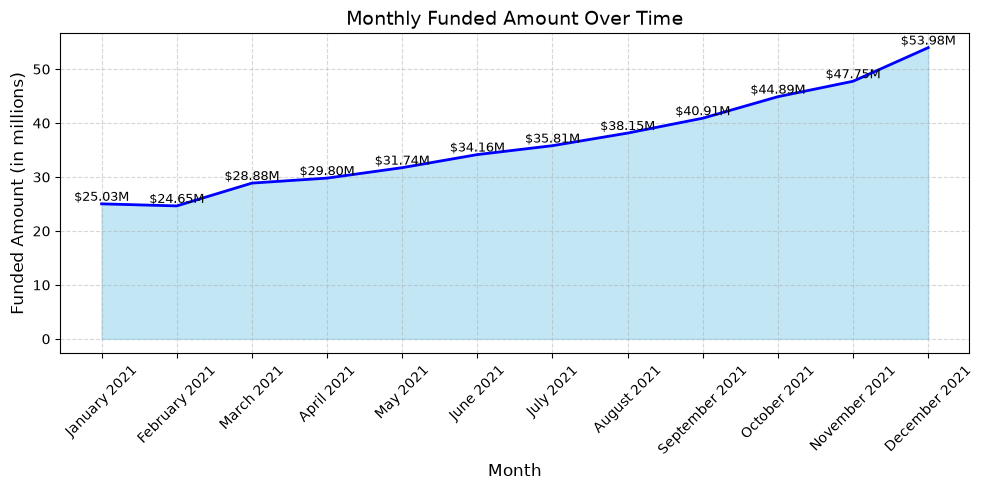

In [21]:
monthly_funded = (
    df.sort_values('issue_date')
      .assign(month_name=lambda x: x['issue_date'].dt.strftime('%B %Y'))
      .groupby('month_name', sort=False)['loan_amount']
      .sum()
      .div(1000000)
      .reset_index(name='loan_amount_millions')
)
plt.figure(figsize=(10, 5))
plt.fill_between(monthly_funded['month_name'], monthly_funded['loan_amount_millions'], color='skyblue', alpha=0.5)
plt.plot(monthly_funded['month_name'], monthly_funded['loan_amount_millions'], linewidth=2, color='blue')

for i, row in monthly_funded.iterrows():
    plt.text(i, row['loan_amount_millions'], f"${row['loan_amount_millions']:.2f}M", ha='center', va='bottom', fontsize=9, color='black')

plt.title('Monthly Funded Amount Over Time', fontsize=14)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Funded Amount (in millions)', fontsize=12)
plt.xticks(ticks=range(len(monthly_funded['month_name'])), labels=monthly_funded['month_name'], rotation=45)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


### Monthly Trend by Issue Date for Total Amount Received

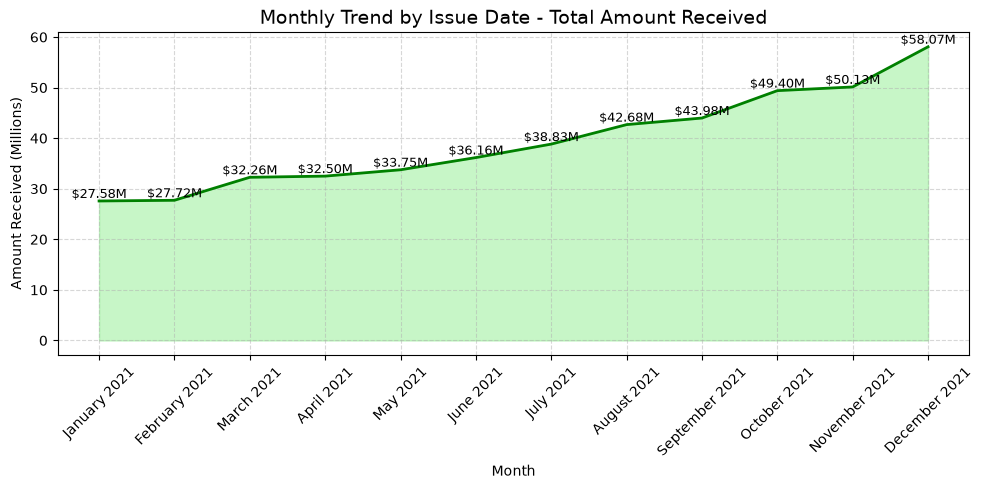

In [30]:
monthly_received = (
    df.sort_values('issue_date')
      .assign(month_name=lambda x: x['issue_date'].dt.strftime('%B %Y'))
      .groupby('month_name', sort=False)['total_payment']
      .sum()
      .div(1000000)
      .reset_index(name='amount_received_millions')
)
plt.figure(figsize=(10, 5))

plt.fill_between(
    monthly_received['month_name'],
    monthly_received['amount_received_millions'],
    color='lightgreen',
    alpha=0.5
)

plt.plot(
    monthly_received['month_name'],
    monthly_received['amount_received_millions'],
    color='green',
    linewidth=2
)

for i, row in monthly_received.iterrows():
    plt.text(
        i,
        row['amount_received_millions'],
        f"${row['amount_received_millions']:.2f}M",
        ha='center',
        va='bottom',
        fontsize=9,
        color='black'
    )

plt.title('Monthly Trend by Issue Date - Total Amount Received', fontsize=14)
plt.xlabel('Month')
plt.ylabel('Amount Received (Millions)')

plt.xticks(
    ticks=range(len(monthly_received)),
    labels=monthly_received['month_name'],
    rotation=45
)

plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()

plt.show()

### Monthly Trends by Issue date for Total loan Applications

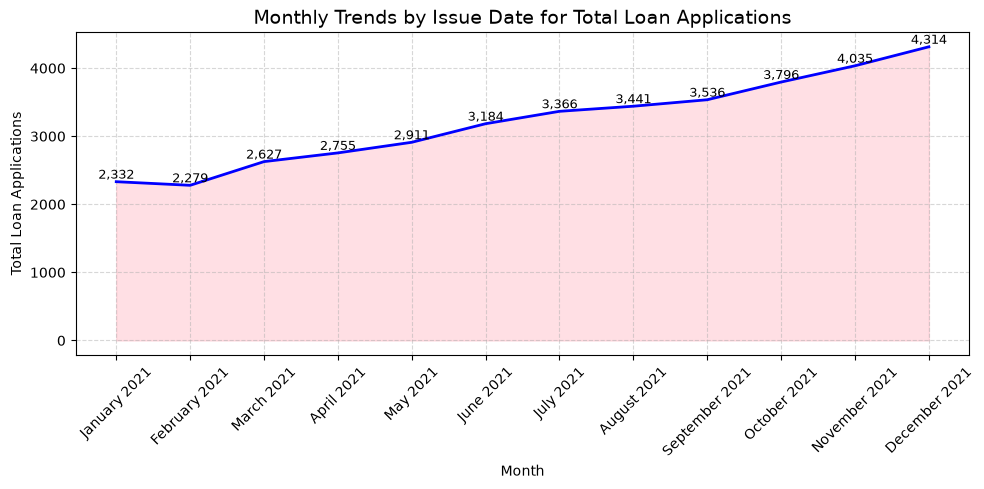

In [29]:
monthly_applications = (
    df.sort_values('issue_date')
      .assign(month_name=lambda x: x['issue_date'].dt.strftime('%B %Y'))
      .groupby('month_name', sort=False)['id']
      .count()
      .reset_index(name='total_loan_applications')
)

plt.figure(figsize=(10, 5))

plt.fill_between(
    monthly_applications['month_name'],
    monthly_applications['total_loan_applications'],
    color='Pink',
    alpha=0.5
)

plt.plot(
    monthly_applications['month_name'],
    monthly_applications['total_loan_applications'],
    color='blue',
    linewidth=2
)

for i, row in monthly_applications.iterrows():
    plt.text(
        i,
        row['total_loan_applications'],
        f"{row['total_loan_applications']:,}",
        ha='center',
        va='bottom',
        fontsize=9,
        color='black'
    )

plt.title('Monthly Trends by Issue Date for Total Loan Applications', fontsize=14)
plt.xlabel('Month')
plt.ylabel('Total Loan Applications')

plt.xticks(
    ticks=range(len(monthly_applications)),
    labels=monthly_applications['month_name'],
    rotation=45
)

plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()

plt.show()

### Regional Analysis by state for total Funded amount

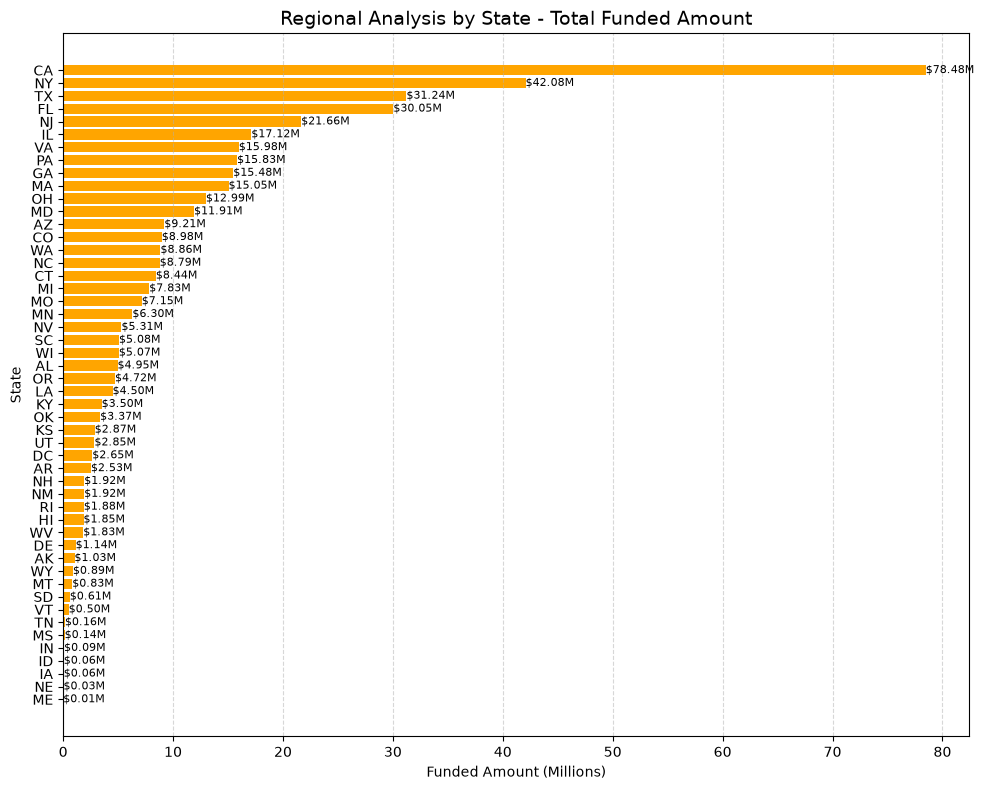

In [ ]:

state_funded = (
    df.groupby('address_state')['loan_amount']
      .sum()
      .div(1000000)
      .sort_values(ascending=True)  # ascending=True works better for horizontal bars
      .reset_index(name='funded_amount_millions')
)

plt.figure(figsize=(10, 8))

plt.barh(
    state_funded['address_state'],
    state_funded['funded_amount_millions'],
    color='Orange'
)

for i, row in state_funded.iterrows():
    plt.text(
        row['funded_amount_millions'],
        i,
        f"${row['funded_amount_millions']:.2f}M",
        va='center',
        fontsize=8
    )


plt.title('Regional Analysis by State - Total Funded Amount', fontsize=14)
plt.xlabel('Funded Amount (Millions)')
plt.ylabel('State')

plt.grid(axis='x', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()


### Loan Term Analysis by Total Funded Amount

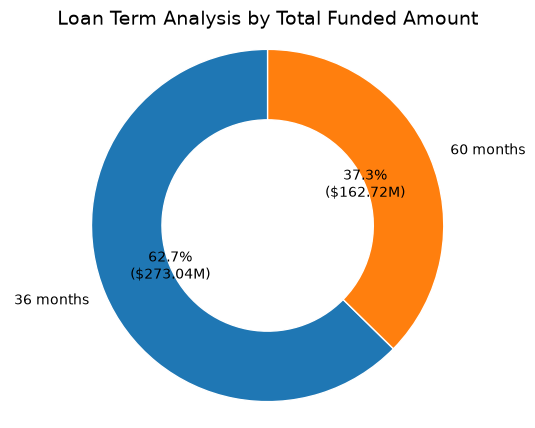

In [35]:
loan_term_funded = (
    df.groupby('term')['loan_amount']
      .sum()
      .div(1000000)
      .reset_index(name='funded_amount_millions')
)

total = loan_term_funded['funded_amount_millions'].sum()

def func(pct):
    amount = pct * total / 100
    return f"{pct:.1f}%\n(${amount:.2f}M)"

plt.figure(figsize=(5,5))

plt.pie(
    loan_term_funded['funded_amount_millions'],
    labels=loan_term_funded['term'],
    autopct=func,
    startangle=90,
    wedgeprops={'width':0.4, 'edgecolor':'white'},
    textprops={'fontsize':10}
)

plt.title('Loan Term Analysis by Total Funded Amount', fontsize=14)

plt.axis('equal')

plt.show()

### Employee Length by Total Funded amount

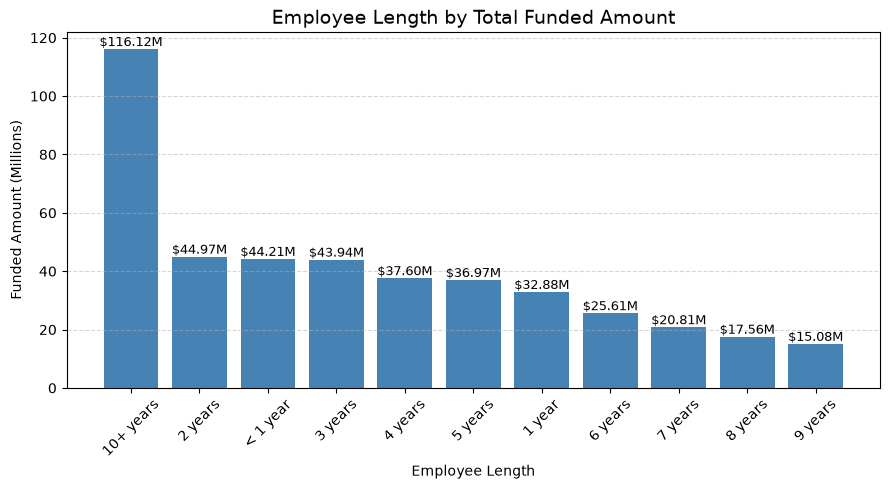

In [37]:
employee_length_funded = (
    df.groupby('emp_length')['loan_amount']
      .sum()
      .div(1000000)
      .sort_values(ascending=False)
      .reset_index(name='funded_amount_millions')
)

plt.figure(figsize=(9,5))

plt.bar(
    employee_length_funded['emp_length'],
    employee_length_funded['funded_amount_millions'],
    color='steelblue'
)

for i, row in employee_length_funded.iterrows():
    plt.text(
        i,
        row['funded_amount_millions'],
        f"${row['funded_amount_millions']:.2f}M",
        ha='center',
        va='bottom',
        fontsize=9
    )

plt.title('Employee Length by Total Funded Amount', fontsize=14)
plt.xlabel('Employee Length')
plt.ylabel('Funded Amount (Millions)')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()    

### Loan purpose by total funded amount

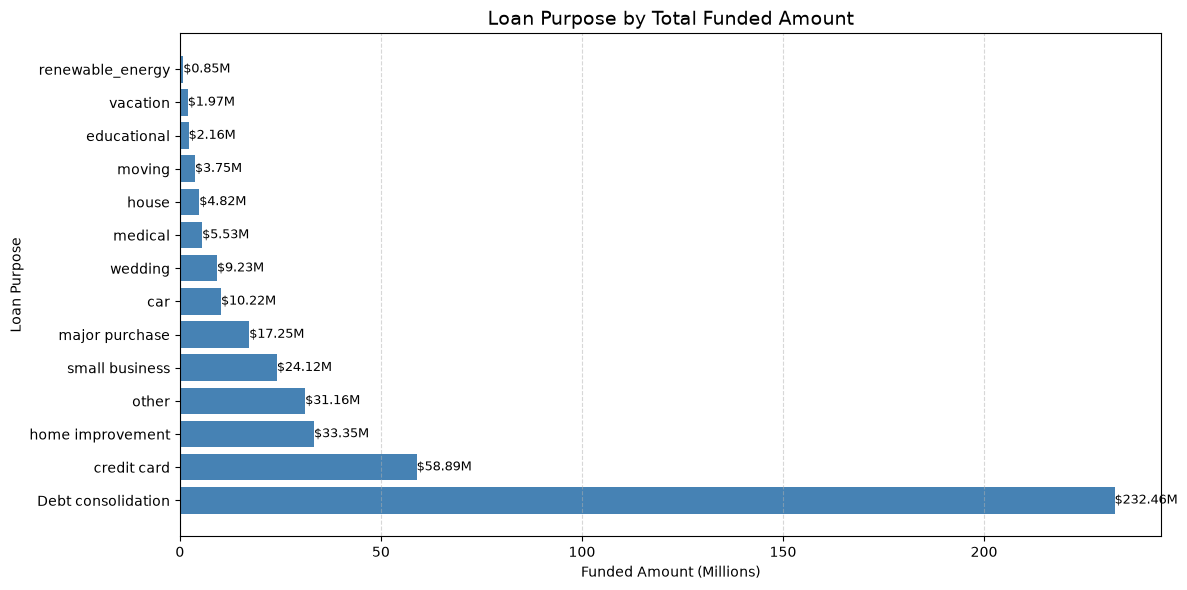

In [39]:
loan_purpose_funded = (
    df.groupby('purpose')['loan_amount']
      .sum()
      .div(1000000)
      .sort_values(ascending=False)
      .reset_index(name='funded_amount_millions')
)

plt.figure(figsize=(12,6))

plt.barh(
    loan_purpose_funded['purpose'],
    loan_purpose_funded['funded_amount_millions'],
    color='steelblue'
)

for i, row in loan_purpose_funded.iterrows():
    plt.text(
        row['funded_amount_millions'],
        i,
        f"${row['funded_amount_millions']:.2f}M",
        ha='left',
        va='center',
        fontsize=9
    )

plt.title('Loan Purpose by Total Funded Amount', fontsize=14)
plt.xlabel('Funded Amount (Millions)')
plt.ylabel('Loan Purpose')
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [44]:
home_funding = (
    df.groupby('home_ownership')['loan_amount']
      .sum()
      .reset_index()
)

home_funding['loan_amount_millions'] = home_funding['loan_amount'] / 1000000

fig = px.treemap(
    home_funding,
    path=['home_ownership'],
    values='loan_amount_millions',
    color='loan_amount_millions',
    color_continuous_scale='Blues',
    title='Home Ownership by Total Funded Amount (Millions)'
)

fig.update_traces(
    texttemplate="<b>%{label}</b><br>$%{value:.2f}M"
)

fig.update_layout(
    margin=dict(t=50, l=20, r=20, b=20)
)

fig.show()